# Exploratory Data Analysis

-- Ładowanie danych i zmiana kolumny z umiejętnościami 

In [3]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
from datasets import load_dataset

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

#loading data
datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(clean_list)

##### Wybranie danych dla regiony Stany Zjednoczone i roli Analityk danych

In [4]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

Top 10 lokalizacji w ogłoszeniach

In [5]:
df_location_counts = df_DA_US['job_location'].value_counts().head(10).to_frame()

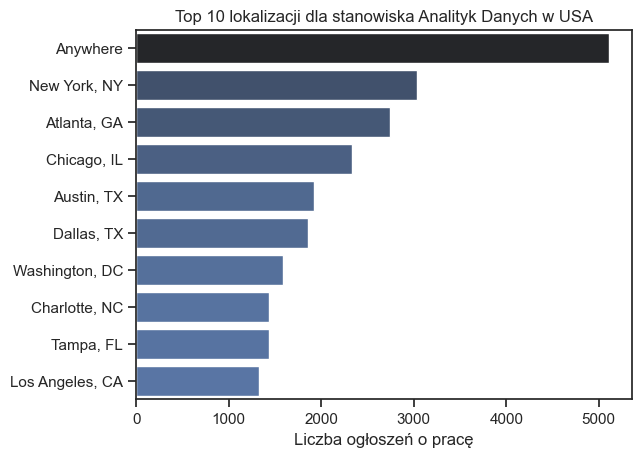

In [16]:
sns.set_theme(style="ticks")
sns.barplot(data=df_location_counts, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
plt.ylabel('')
plt.xlabel('Liczba ogłoszeń o pracę')
plt.title('Top 10 lokalizacji dla stanowiska Analityk Danych w USA')   
plt.show()

Dodatkowe parametry edukacyjne i socjalne w ogłoszeniach

In [13]:
columns = [('job_work_from_home', 'Praca z domu'), ('job_no_degree_mention', 'Wykształcenie wyższe'), ('job_health_insurance', 'Ubezpieczenie zdrowotne')]

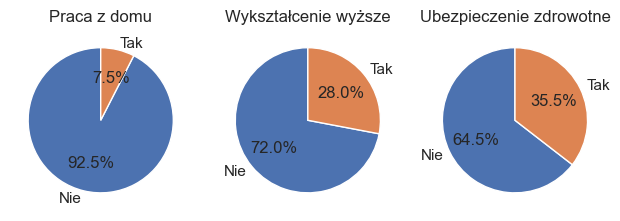

In [15]:
fig, ax = plt.subplots(1, 3)
for i, col in enumerate(columns):
    col
    df_DA_US[col[0]].value_counts().plot(kind='pie', ax=ax[i], startangle=90, autopct='%1.1f%%', labels=['Nie', 'Tak'])
    ax[i].set_title(f'{col[1]}')
    ax[i].set_ylabel('')

fig.tight_layout()
plt.show()

Firmy z największą liczbą ogłoszeń

In [10]:
df_company_counts = df_DA_US['company_name'].value_counts().head(10).to_frame()

In [11]:
df_company_counts

,count
company_name,
Robert Half,959
Insight Global,827
Dice,584
UnitedHealth Group,507
Get It Recruit - Information Technology,503
Citi,477
Corporate,416
SynergisticIT,374
Centene Corporation,350


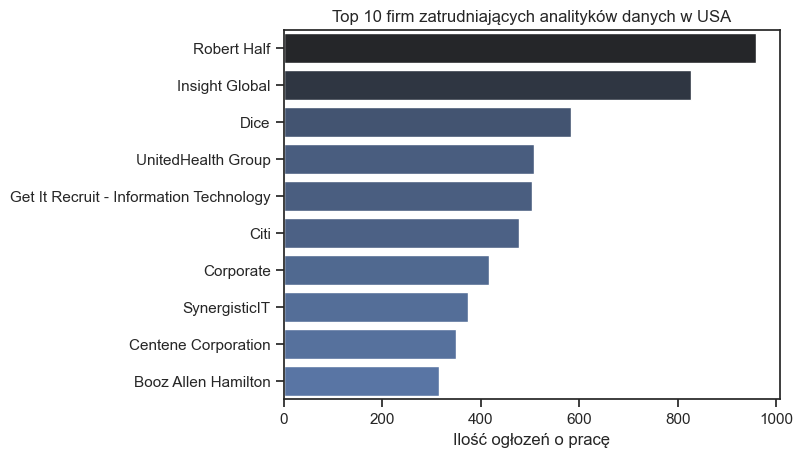

In [12]:
sns.set_theme(style="ticks")
sns.barplot(data=df_company_counts, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.ylabel('')
plt.xlabel('Ilość ogłozeń o pracę')
plt.title('Top 10 firm zatrudniających analityków danych w USA')   
plt.show()